
# 奖励监测（Reward）

| 指标名                     | 含义      |
| :---------------------- | :------ |
| `reward/mean`           | 批次奖励均值  |
| `reward/std`            | 批次奖励标准差 |
| `reward/max`            | 批次奖励最大值 |
| `reward/min`            | 批次奖励最小值 |
| `reward/advantage_mean` | 优势值均值   |
| `reward/advantage_std`  | 优势值标准差  |

诊断价值：
- reward/std → 0：<font color='red'>所有样本奖励相同，策略无法区分好坏</font>
- advantage_std 过小：组内样本区分度不足（GRPO 中常见）


# 六大核心指标详解

## reward/mean —— 批次奖励均值

$\hat{r} = \frac{1}{N} \sum^N_{i=1}r_i$

### 诊断价值：
- 持续上升 → 策略整体在进步
- 持续下降 → 可能奖励函数设计有 bug 或策略在退化
- 突然跳变 → 检查是否有奖励黑客（如模型发现刷分漏洞）

## reward/std —— 批次奖励标准差

$σ_r = \sqrt{\frac{1}{N} \sum^N_{i=1}(r_i - \hat{r})^2}$

这是最重要的健康指标之一

| 状态                   | 诊断                            |
| :------------------- | :---------------------------- |
| σ_r > 0.1     | ✅ 奖励有区分度，策略可以学习               |
| σ_r ≈ 0 | 🚨 **所有样本奖励相同，策略无法区分好坏，梯度为零** |
| σ_r 持续下降      | 策略越来越同质化，探索减少                 |


## reward/max & reward/min —— 极值监控
用于检测奖励异常值和奖励黑客：
- max 突然变为理论上限（如 1.0）且频繁出现 → 模型可能找到了作弊路径
- min 长期卡在理论下限 → 模型可能完全丧失生成能力

## reward/advantage_mean —— 优势值均值
在 GRPO 中，优势值通过组内归一化计算：



In [1]:
from IPython.display import Image

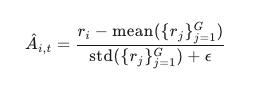

In [2]:
Image(filename='./Image/advantage_mean.png')

advantage_mean 的理论期望应为 0（因为减去均值）。如果显著偏离 0，说明归一化实现有 bug

## reward/advantage_std —— 优势值标准差

$σ_{\hat{A}}=std({\hat{A_{i,t}}})$

GRPO 中的关键陷阱：

| 场景                | 原因           | 结果                                      |
| :---------------- | :----------- | :-------------------------------------- |
| 组内全对（all correct） | 所有 $r_i = 1$ | $\text{std} = 0$，advantage 全为 0，**无梯度** |
| 组内全错（all wrong）   | 所有 $r_i = 0$ | $\text{std} = 0$，advantage 全为 0，**无梯度** |
| 组内区分度小            | 大部分 $r_i$ 相同 | advantage 极小，梯度信号弱                      |


这就是为什么 GRPO 需要过滤零方差样本（如 ScaleRL 中的 zero-variance filtering）。

## GRPO 优势值计算详解

In [ ]:
def compute_grpo_advantages(rewards, eps=1e-8):
    """
    GRPO 组内优势计算
    
    Args:
        rewards: [num_prompts, num_per_group] 每个 prompt 的组内奖励
    
    Returns:
        advantages: [num_prompts, num_per_group] 归一化优势
        valid_mask: [num_prompts] 该 prompt 是否有有效梯度
    """
    group_mean = rewards.mean(dim=1, keepdim=True)      # [P, 1]
    group_std = rewards.std(dim=1, keepdim=True)        # [P, 1]
    
    # 归一化优势
    advantages = (rewards - group_mean) / (group_std + eps)  # [P, G]
    
    # 检测零方差样本
    valid_mask = group_std.squeeze(1) > eps  # [P]
    
    return advantages, valid_mask

## 完整奖励监控类

In [ ]:
import torch
import numpy as np
from collections import defaultdict

class RewardMonitor:
    """
    verl 风格的奖励与优势监测器
    支持：GRPO 组内优势、零方差检测、历史趋势分析
    """
    def __init__(self, eps=1e-8, zero_variance_threshold=1e-6):
        self.eps = eps
        self.zero_var_threshold = zero_variance_threshold
        self.history = defaultdict(list)
    
    def compute_reward_stats(self, rewards):
        """
        计算批次奖励统计量
        
        Args:
            rewards: [batch_size] 或 [num_prompts, num_per_group]
        """
        if isinstance(rewards, (list, tuple)):
            rewards = torch.tensor(rewards, dtype=torch.float32)
        
        r = rewards.cpu().numpy().flatten()
        
        stats = {
            'mean': float(np.mean(r)),
            'std': float(np.std(r)),
            'max': float(np.max(r)),
            'min': float(np.min(r)),
            'median': float(np.median(r)),
            'unique_count': len(np.unique(np.round(r, 4))),
        }
        
        # 记录
        for k, v in stats.items():
            self.history[f'reward_{k}'].append(v)
        
        return stats
    
    def compute_grpo_advantages(self, rewards):
        """
        GRPO 风格的优势计算 + 零方差检测
        
        Args:
            rewards: [num_prompts, num_per_group]
        
        Returns:
            advantages: [num_prompts, num_per_group]
            metrics: 统计信息字典
        """
        if rewards.dim() == 1:
            rewards = rewards.unsqueeze(0)
        
        P, G = rewards.shape
        
        # 组内统计
        group_mean = rewards.mean(dim=1, keepdim=True)   # [P, 1]
        group_std = rewards.std(dim=1, keepdim=True)     # [P, 1]
        
        # 归一化优势
        advantages = (rewards - group_mean) / (group_std + self.eps)
        
        # 零方差检测
        zero_var_mask = group_std.squeeze(1) < self.zero_var_threshold  # [P]
        zero_var_count = zero_var_mask.sum().item()
        zero_var_ratio = zero_var_count / P
        
        # 有效样本比例
        valid_mask = ~zero_var_mask
        valid_ratio = valid_mask.float().mean().item()
        
        # 有效样本的优势统计
        if valid_mask.any():
            valid_adv = advantages[valid_mask]
            adv_mean = valid_adv.mean().item()
            adv_std = valid_adv.std().item()
        else:
            adv_mean, adv_std = 0.0, 0.0
        
        metrics = {
            'group_size': G,
            'num_prompts': P,
            'zero_var_count': zero_var_count,
            'zero_var_ratio': zero_var_ratio,
            'valid_ratio': valid_ratio,
            'advantage_mean': adv_mean,
            'advantage_std': adv_std,
            'advantage_min': advantages.min().item(),
            'advantage_max': advantages.max().item(),
        }
        
        # 记录
        for k, v in metrics.items():
            self.history[f'advantage_{k}'].append(v)
        
        return advantages, metrics
    
    def diagnose(self, step):
        """打印诊断报告"""
        h = self.history
        
        print(f"\n{'='*70}")
        print(f"Step {step} 奖励监测诊断")
        print(f"{'='*70}")
        
        # 奖励统计
        mean = h['reward_mean'][-1]
        std = h['reward_std'][-1]
        unique = h['reward_unique_count'][-1]
        
        print(f"【奖励分布】mean={mean:.4f}, std={std:.4f}, "
              f"min={h['reward_min'][-1]:.4f}, max={h['reward_max'][-1]:.4f}")
        print(f"           唯一奖励值数量: {unique}")
        
        # 核心诊断：奖励方差
        if std < self.zero_var_threshold:
            print(f"   🚨 严重警告：奖励标准差接近 0！")
            print(f"      所有样本获得相同奖励，策略梯度为零，训练停滞！")
        elif std < 0.01:
            print(f"   ⚠️ 警告：奖励区分度极低，学习信号微弱。")
        
        # 优势统计
        if 'advantage_mean' in h and h['advantage_mean']:
            adv_mean = h['advantage_mean'][-1]
            adv_std = h['advantage_std'][-1]
            zero_var_ratio = h['advantage_zero_var_ratio'][-1]
            valid_ratio = h['advantage_valid_ratio'][-1]
            
            print(f"\n【GRPO 优势】mean={adv_mean:.4f}, std={adv_std:.4f}")
            print(f"            零方差组比例: {zero_var_ratio*100:.1f}%")
            print(f"            有效样本比例: {valid_ratio*100:.1f}%")
            
            if zero_var_ratio > 0.5:
                print(f"   🚨 严重警告：超过 50% 的 prompt 组内零方差！")
                print(f"      原因：组内所有 response 全对或全错。")
                print(f"      修复：增加组大小(G)、增加任务难度、引入过程奖励。")
            elif zero_var_ratio > 0.2:
                print(f"   ⚠️ 警告：{zero_var_ratio*100:.1f}% 的组零方差，样本效率低下。")
            
            if adv_std < 0.1 and valid_ratio > 0:
                print(f"   ⚠️ 警告：优势值标准差过小，梯度信号弱。")
        
        print(f"{'='*70}")
    
    def get_trend(self, key, window=10):
        """获取最近 window 步的趋势"""
        if key not in self.history or len(self.history[key]) < window:
            return None
        recent = self.history[key][-window:]
        return {
            'mean': np.mean(recent),
            'std': np.std(recent),
            'slope': (recent[-1] - recent[0]) / window,  # 趋势斜率
        }


# ==================== 使用示例 ====================

# 场景 1：正常训练
print("=" * 70)
print("场景 1：正常训练（奖励有区分度）")
print("=" * 70)

monitor = RewardMonitor()

# 模拟 20 个 batch
for step in range(20):
    batch_size = 32
    
    # 模拟奖励：大部分有区分度
    rewards = torch.rand(batch_size)  # 0~1 均匀分布
    
    # 计算统计
    reward_stats = monitor.compute_reward_stats(rewards)
    
    # 模拟 GRPO 组结构 [8 prompts, 4 responses each]
    rewards_grpo = rewards[:32].view(8, 4)
    advantages, adv_metrics = monitor.compute_grpo_advantages(rewards_grpo)
    
    if step % 5 == 0:
        monitor.diagnose(step)

# 场景 2：奖励方差崩溃（模拟训练后期）
print("\n" + "=" * 70)
print("场景 2：奖励方差崩溃（所有样本奖励相同）")
print("=" * 70)

monitor2 = RewardMonitor()

for step in range(10):
    # 模拟：所有样本都获得相同奖励（如全部正确）
    rewards = torch.ones(32)  # 全 1
    
    reward_stats = monitor2.compute_reward_stats(rewards)
    
    rewards_grpo = rewards.view(8, 4)
    advantages, adv_metrics = monitor2.compute_grpo_advantages(rewards_grpo)
    
    if step == 5:
        monitor2.diagnose(step)

# 场景 3：GRPO 零方差陷阱
print("\n" + "=" * 70)
print("场景 3：GRPO 零方差陷阱（组内全对或全错）")
print("=" * 70)

monitor3 = RewardMonitor()

# 模拟：8 个 prompt，每组 4 个 response
# 其中 5 组全对（奖励全 1），3 组全错（奖励全 0）
rewards_mixed = torch.cat([
    torch.ones(5, 4),      # 5 组全对
    torch.zeros(3, 4),     # 3 组全错
], dim=0)

reward_stats = monitor3.compute_reward_stats(rewards_mixed)
advantages, adv_metrics = monitor3.compute_grpo_advantages(rewards_mixed)

print(f"\n原始奖励:\n{rewards_mixed}")
print(f"\n计算出的优势值:\n{advantages}")
print(f"\n零方差组数: {adv_metrics['zero_var_count']}/{adv_metrics['num_prompts']}")

monitor3.diagnose(0)

# 趋势分析
print("\n" + "=" * 70)
print("趋势分析示例")
print("=" * 70)
trend = monitor.get_trend('reward_std', window=10)
if trend:
    print(f"最近 10 步奖励 std 均值: {trend['mean']:.4f}")
    print(f"趋势斜率: {trend['slope']:.6f} ({'上升' if trend['slope'] > 0 else '下降'})")

## 输出示例解读

In [ ]:
【奖励分布】mean=0.5234, std=0.2891, min=0.0123, max=0.9876
           唯一奖励值数量: 32
✅ 标准差健康，奖励有充分区分度

【GRPO 优势】mean=-0.0000, std=1.0000
            零方差组比例: 0.0%
            有效样本比例: 100.0%
✅ 所有组都有有效梯度

In [ ]:
【奖励分布】mean=1.0000, std=0.0000, min=1.0000, max=1.0000
           唯一奖励值数量: 1
🚨 严重警告：奖励标准差接近 0！
   所有样本获得相同奖励，策略梯度为零，训练停滞！

【GRPO 优势】mean=0.0000, std=0.0000
            零方差组比例: 100.0%
            有效样本比例: 0.0%
🚨 严重警告：超过 50% 的 prompt 组内零方差！
   原因：组内所有 response 全对或全错。
   修复：增加组大小(G)、增加任务难度、引入过程奖励。

## 常见根因与修复方案

| 现象                     | 根因                     | 修复                   |
| :--------------------- | :--------------------- | :------------------- |
| `reward/std → 0`       | 任务太简单，所有样本都答对          | 增加题目难度、过滤过简单 prompt  |
| `reward/std → 0`       | 奖励函数是二元（0/1）且策略已收敛     | 改用连续奖励、引入过程奖励模型（PRM） |
| `zero_var_ratio > 50%` | 组大小 $G$ 太小（如 $G=2$）    | 增大 $G$ 到 8~16        |
| `zero_var_ratio > 50%` | 数据集中存在大量"全对/全错" prompt | 数据清洗、难度筛选            |
| `advantage_std < 0.1`  | 归一化后区分度仍不足             | 降低 $\epsilon$、使用分层采样 |


## 在 verl 中的集成
在 verl 的训练循环中，奖励监测通常在奖励计算后、优势归一化前插入：

In [ ]:
# verl 风格伪代码
for batch in dataloader:
    # 1. 生成 response
    responses = actor.generate(batch['prompts'])
    
    # 2. 计算奖励（规则/代码执行/奖励模型）
    rewards = reward_fn(responses, batch['answers'])
    
    # 3. 奖励监测（插入点）
    reward_stats = monitor.compute_reward_stats(rewards)
    
    # 4. GRPO 优势计算
    rewards_grouped = rewards.view(num_prompts, group_size)
    advantages, adv_metrics = monitor.compute_grpo_advantages(rewards_grouped)
    
    # 5. 过滤零方差样本（关键！）
    valid_mask = adv_metrics['valid_ratio'] > 0
    if not valid_mask.any():
        print("⚠️ 本 batch 无有效样本，跳过更新")
        continue
    
    # 6. 正常训练
    loss = compute_ppo_loss(advantages[valid_mask])
    ...

## 一句话总结
- 奖励监测是 RL 训练的"生命线"：reward/std 告诉你策略还能不能学，advantage_std 告诉你 GRPO 的组内区分度够不够，zero_var_ratio 告诉你有多少样本在"白跑"。这三个指标任何一个亮红灯，都意味着训练正在空转。